# Optimizers and schedulers

## Data

### Imports

In [108]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from scipy.ndimage import gaussian_filter1d

### Data generation

In [109]:
def generate_regression_data(num_samples=1000):
    input_data = np.linspace(0.1, 5, num_samples)
    target_data = np.piecewise(
        input_data,
        [input_data < 2, (input_data >= 2) & (input_data < 4), input_data >= 4],
        [
            lambda x: np.sin(3 * x),
            lambda x: x**2 - x + 7,
            lambda x: np.exp(x) + np.cos(3 * x)
        ]
    )
    target_data += np.random.normal(0, 0.02, size=input_data.shape)
    return input_data.reshape(-1, 1), target_data.reshape(-1, 1)

### Generic model

In [110]:
class SimpleRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential_layers = nn.Sequential(
            nn.Linear(1, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.sequential_layers(x)

### Optimizers

### Nesterov

In [111]:
class NesterovOptimizer:
    def __init__(self, params, learning_rate=0.003, momentum_factor=0.9):
        self.params = list(params)
        self.learning_rate = learning_rate
        self.momentum_factor = momentum_factor
        self.velocity = {param: torch.zeros_like(param.data) for param in self.params}
    def step(self):
        for param in self.params:
            if param.grad is None:
                continue
            gradient = param.grad
            self.velocity[param] = self.momentum_factor * self.velocity[param] + self.learning_rate * gradient
            param.data -= self.momentum_factor * self.velocity[param] + self.learning_rate * gradient
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

### Adam

In [112]:
class AdamOptimizer:
    def __init__(self, params, learning_rate=0.003, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.params = list(params)
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.time_step = 0
        self.moment_1 = {param: torch.zeros_like(param.data) for param in self.params}
        self.moment_2 = {param: torch.zeros_like(param.data) for param in self.params}
    def step(self):
        self.time_step += 1
        for param in self.params:
            if param.grad is None:
                continue
            gradient = param.grad
            self.moment_1[param] = self.beta1 * self.moment_1[param] + (1 - self.beta1) * gradient
            self.moment_2[param] = self.beta2 * self.moment_2[param] + (1 - self.beta2) * gradient**2
            moment_1_corrected = self.moment_1[param] / (1 - self.beta1 ** self.time_step)
            moment_2_corrected = self.moment_2[param] / (1 - self.beta2 ** self.time_step)
            param.data -= self.learning_rate * moment_1_corrected / (torch.sqrt(moment_2_corrected) + self.epsilon)
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

### RMSProp

In [113]:
class RMSpropOptimizer:
    def __init__(self, params, learning_rate=0.003, decay_rate=0.99, epsilon=1e-4):
        self.params = list(params)
        self.learning_rate = learning_rate
        self.decay_rate = decay_rate
        self.epsilon = epsilon
        self.squared_avg_grad = {param: torch.zeros_like(param.data) for param in self.params}
    def step(self):
        for param in self.params:
            if param.grad is None:
                continue
            gradient = param.grad
            self.squared_avg_grad[param] = self.decay_rate * self.squared_avg_grad[param] + (1 - self.decay_rate) * gradient**2
            param.data -= self.learning_rate * gradient / (torch.sqrt(self.squared_avg_grad[param]) + self.epsilon)
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

## Schedulers

### StepLR

In [114]:
class StepLRScheduler:
    def __init__(self, optimizer, step_size, gamma_factor):
        self.optimizer = optimizer
        self.step_size = step_size
        self.gamma_factor = gamma_factor
        self.current_epoch = 0
    def step(self):
        self.current_epoch += 1
        if self.current_epoch % self.step_size == 0:
            self.optimizer.learning_rate *= self.gamma_factor

### ExponentialLR

In [115]:
class ExponentialLRScheduler:
    def __init__(self, optimizer, gamma_factor):
        self.optimizer = optimizer
        self.gamma_factor = gamma_factor
    def step(self):
        self.optimizer.learning_rate *= self.gamma_factor

## Training

In [116]:
def train_regression_model(optimizer_name, scheduler_name, scheduler_params, num_epochs=150, initial_learning_rate=0.003):
    X, Y = generate_regression_data(5000)
    x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

    model = SimpleRegressionNN()
    loss_criterion = nn.HuberLoss()

    if optimizer_name == "Nesterov":
        optimizer = NesterovOptimizer(model.parameters(), learning_rate=initial_learning_rate)
    elif optimizer_name == "Adam":
        optimizer = AdamOptimizer(model.parameters(), learning_rate=initial_learning_rate)
    elif optimizer_name == "RMSprop":
        optimizer = RMSpropOptimizer(model.parameters(), learning_rate=initial_learning_rate)

    if scheduler_name == "StepLR":
        scheduler = StepLRScheduler(optimizer, **scheduler_params)
    elif scheduler_name == "ExponentialLR":
        scheduler = ExponentialLRScheduler(optimizer, **scheduler_params)

    learning_rates = []
    validation_losses = []

    for epoch in range(num_epochs):
        model.train()
        predictions = model(x_train_tensor)
        loss = loss_criterion(predictions, y_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(x_val_tensor)
            val_loss = loss_criterion(val_predictions, y_val_tensor)

        learning_rates.append(optimizer.learning_rate)
        validation_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f"[{optimizer_name} + {scheduler_name}] [Epoch {epoch}] val_loss = {val_loss.item():.4f}, learning_rate = {optimizer.learning_rate:.5f}")

    return learning_rates, gaussian_filter1d(validation_losses, sigma=2)

### Training combinations

In [117]:
experiment_combinations = [
    ("Nesterov", "StepLR"),
    ("Nesterov", "ExponentialLR"),
    ("Adam", "StepLR"),
    ("Adam", "ExponentialLR"),
    ("RMSprop", "StepLR"),
    ("RMSprop", "ExponentialLR")
]

scheduler_configurations = {
    "StepLR": {"step_size": 20, "gamma_factor": 0.5},
    "ExponentialLR": {"gamma_factor": 0.95}
}

### Marker styles

In [118]:
plot_styles = {
    "Nesterov & StepLR": ("blue", "-", "o"),
    "Nesterov & ExponentialLR": ("purple", "--", "s"),
    "Adam & StepLR": ("red", "-.", "^"),
    "Adam & ExponentialLR": ("green", ":", "D"),
    "RMSprop & StepLR": ("orange", (0, (5, 2)), "*"),
    "RMSprop & ExponentialLR": ("yellow", (0, (3, 1, 1, 1)), "+")
}

### Execution

In [119]:
lr_history = {}
val_loss_history = {}
num_epochs = 150

for o, s in experiment_combinations:
    label = f"{o} & {s}"
    print(f"\n ----+ {label} +----")
    lrs, vloss = train_regression_model(o, s, scheduler_configurations[s], num_epochs=num_epochs, initial_learning_rate=0.003)
    lr_history[label] = lrs
    val_loss_history[label] = vloss
    print(f"{label} (!) final validation loss: {vloss[-1]:.4f}")


 ----+ Nesterov & StepLR +----
[Nesterov + StepLR] [Epoch 0] val_loss = 24.3102, learning_rate = 0.00300
[Nesterov + StepLR] [Epoch 10] val_loss = 23.9278, learning_rate = 0.00300
[Nesterov + StepLR] [Epoch 20] val_loss = 19.7940, learning_rate = 0.00150
[Nesterov + StepLR] [Epoch 30] val_loss = 16.8464, learning_rate = 0.00150
[Nesterov + StepLR] [Epoch 40] val_loss = 16.2312, learning_rate = 0.00075
[Nesterov + StepLR] [Epoch 50] val_loss = 15.7743, learning_rate = 0.00075
[Nesterov + StepLR] [Epoch 60] val_loss = 15.4593, learning_rate = 0.00038
[Nesterov + StepLR] [Epoch 70] val_loss = 15.2467, learning_rate = 0.00038
[Nesterov + StepLR] [Epoch 80] val_loss = 15.0691, learning_rate = 0.00019
[Nesterov + StepLR] [Epoch 90] val_loss = 14.9365, learning_rate = 0.00019
[Nesterov + StepLR] [Epoch 100] val_loss = 14.8316, learning_rate = 0.00009
[Nesterov + StepLR] [Epoch 110] val_loss = 14.7580, learning_rate = 0.00009
[Nesterov + StepLR] [Epoch 120] val_loss = 14.7010, learning_rate =

### Plotting

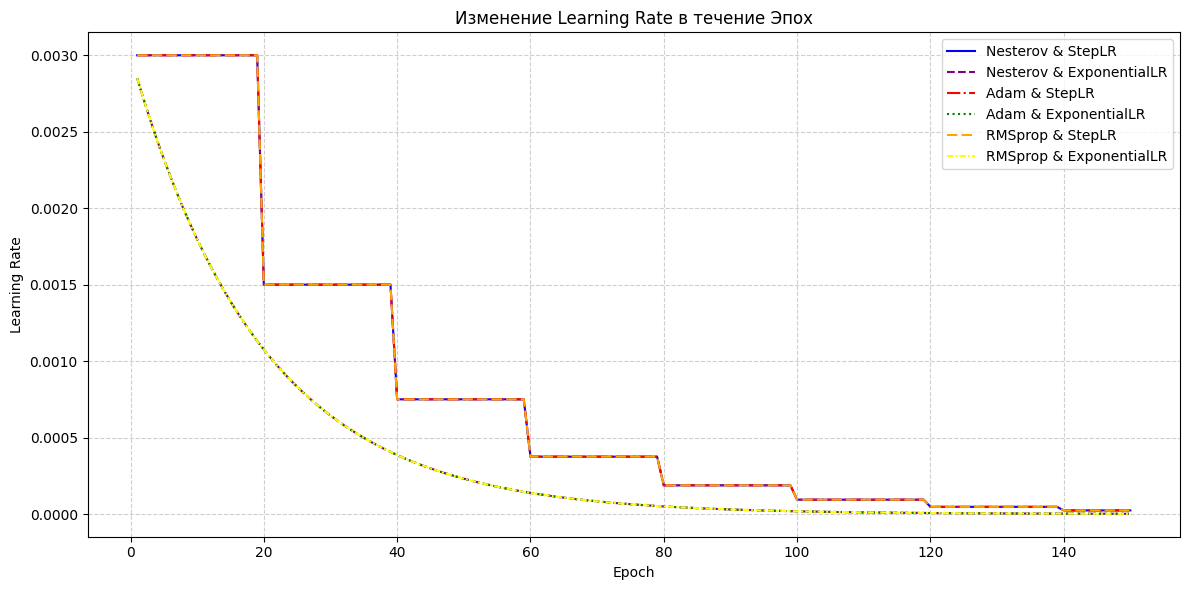

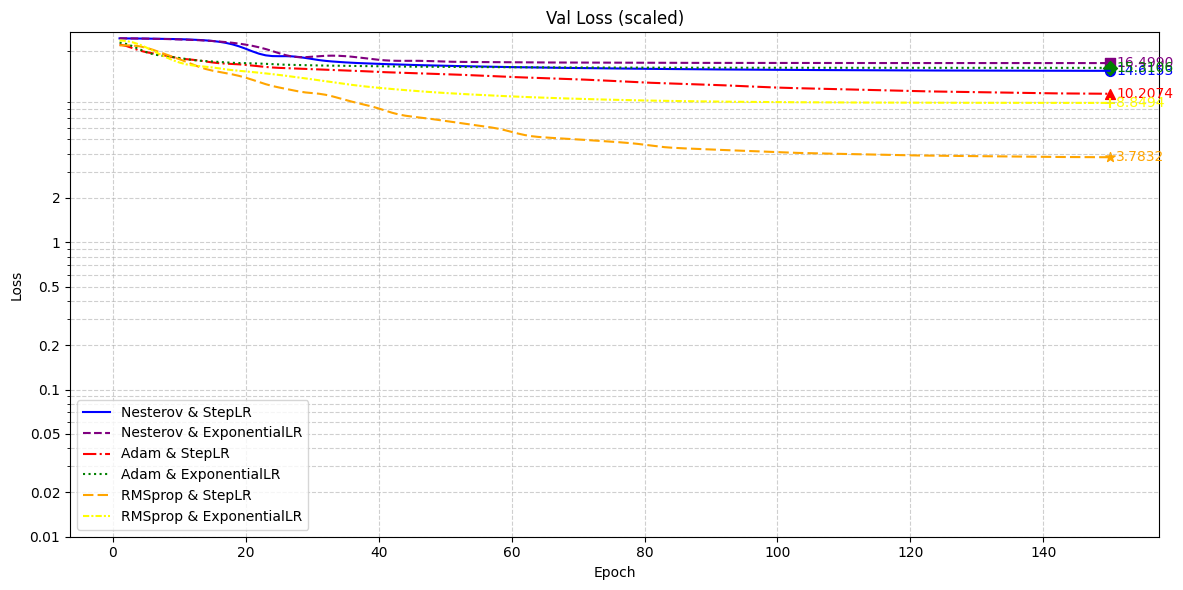

In [121]:
plt.figure(figsize=(12, 6))
for label, (color, line_style, _) in plot_styles.items():
    plt.plot(range(1, num_epochs + 1), lr_history[label], label=label, color=color, linestyle=line_style)
plt.title("Изменение Learning Rate в течение Эпох")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for label, (color, line_style, marker) in plot_styles.items():
    losses = val_loss_history[label]
    plt.plot(range(1, num_epochs + 1), losses, label=label, color=color, linestyle=line_style)
    plt.scatter(num_epochs, losses[-1], color=color, marker=marker, s=50)
    plt.text(num_epochs + 1, losses[-1], f'{losses[-1]:.4f}', fontsize=10, va='center', color=color)
plt.title("Val Loss (scaled)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
ax = plt.gca()
y_ticks = [1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1, 1e0, 2e0]
ax.set_yticks(y_ticks)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}'))
plt.legend()
plt.tight_layout()
plt.show()